In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.mixture import GaussianMixture

(np.float64(-0.5), np.float64(4031.5), np.float64(2267.5), np.float64(-0.5))

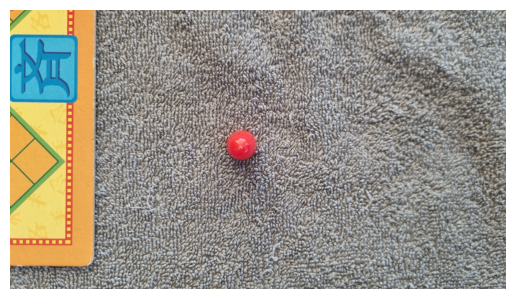

In [2]:
img = mpimg.imread("data/pawn_red.jpg")
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(4031.5), np.float64(2267.5), np.float64(-0.5))

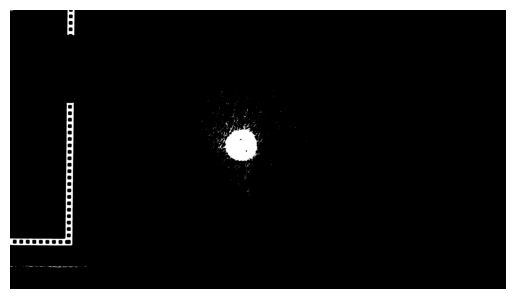

In [3]:
# img loaded via matplotlib -> RGB
img_rgb = img.copy()

# Convert to HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Red color ranges (two ranges!)
lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

red_mask = mask1 | mask2

plt.imshow(red_mask, cmap="gray")
plt.axis("off")


(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

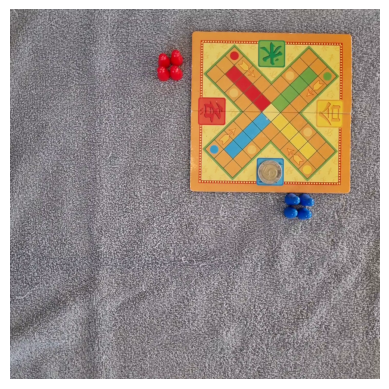

In [4]:
cap = cv2.VideoCapture("data/vid_1.mp4")

ret, frame = cap.read()   # reads the first frame
cap.release()

if not ret:
    raise RuntimeError("Could not read frame")

# OpenCV loads in BGR → convert to RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.axis("off")

(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

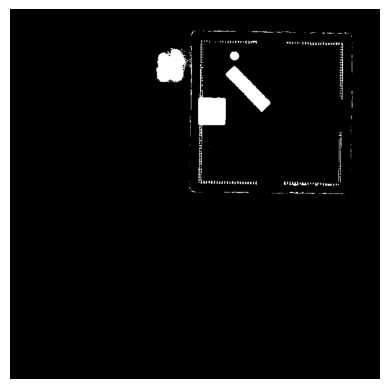

In [5]:
# img loaded via matplotlib -> RGB
img_rgb = frame_rgb.copy()

# Convert to HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Red color ranges (two ranges!)
lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

red_mask = mask1 | mask2

plt.imshow(red_mask, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

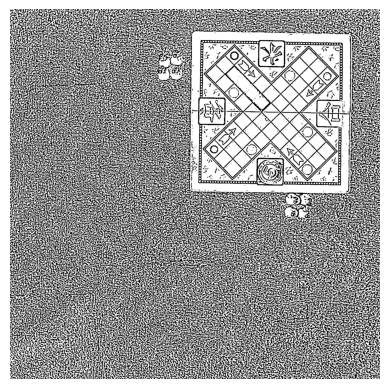

In [6]:
# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Optional but strongly recommended: denoise
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Adaptive thresholding
th = cv2.adaptiveThreshold(
    gray_blur,
    maxValue=255,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # or MEAN_C
    thresholdType=cv2.THRESH_BINARY,                # or THRESH_BINARY_INV
    blockSize=11,                                   # must be odd
    C=2                                             # constant subtracted from mean
)

# Visualization
plt.imshow(th, cmap="gray")
plt.axis("off")


(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

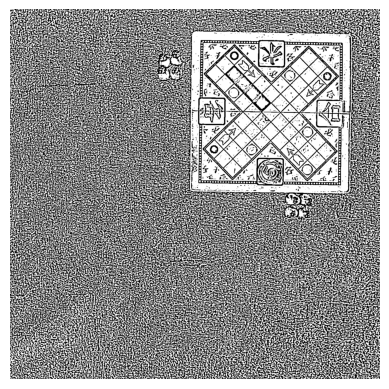

In [7]:
# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Optional but strongly recommended: denoise
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Adaptive thresholding
th = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)


# Visualization
plt.imshow(th, cmap="gray")
plt.axis("off")


(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

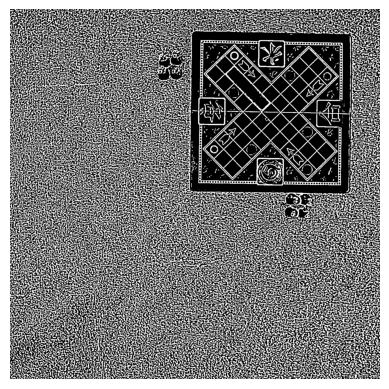

In [8]:
# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Optional but strongly recommended: denoise
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Adaptive thresholding
th = cv2.adaptiveThreshold(
    gray_blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15, 3
)

# Visualization
plt.imshow(th, cmap="gray")
plt.axis("off")


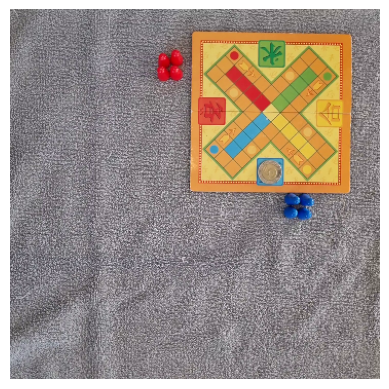

In [43]:
def imshow(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

ludo = frame.copy()
ludo = cv2.resize(ludo, None, fx=0.25, fy=0.25)
imshow(ludo)

In [44]:
# ludo_hsv = cv2.cvtColor(ludo, cv2.COLOR_BGR2HSV)
# pixels = ludo_hsv.reshape(-1, 3).astype(np.float32)

In [45]:
pixels = ludo.reshape(-1, 3).astype(np.float32)

In [46]:
n_components = 9
gmm = GaussianMixture(
    n_components=n_components,
    covariance_type="full",
    random_state=42
)

gmm.fit(pixels)

,n_components,9
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [47]:
labels = gmm.predict(pixels)

In [48]:
cluster_colors = np.zeros((n_components, 3), dtype=np.float32)

for i in range(n_components):
    cluster_colors[i] = pixels[labels == i].mean(axis=0)

segmented_pixels = cluster_colors[labels]
segmented = segmented_pixels.reshape(ludo.shape).astype(np.uint8)

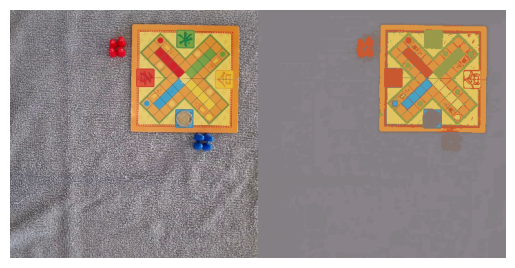

In [49]:
imshow(np.hstack([ludo, segmented]))

(np.float64(-0.5), np.float64(359.5), np.float64(359.5), np.float64(-0.5))

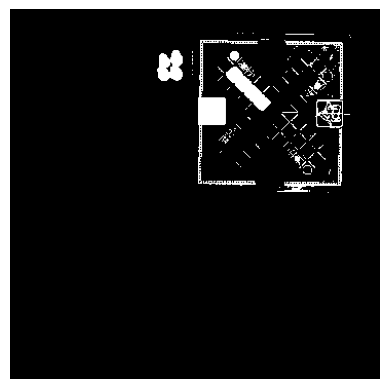

In [50]:
# find cluster closest to red
red_ref = np.array([0, 0, 255], dtype=np.float32)  # BGR
distances = np.linalg.norm(cluster_colors - red_ref, axis=1)
red_cluster = np.argmin(distances)

red_mask = (labels == red_cluster).reshape(ludo.shape[:2])

plt.imshow(red_mask, cmap="gray")
plt.axis("off")

In [51]:
ludo = frame.copy()

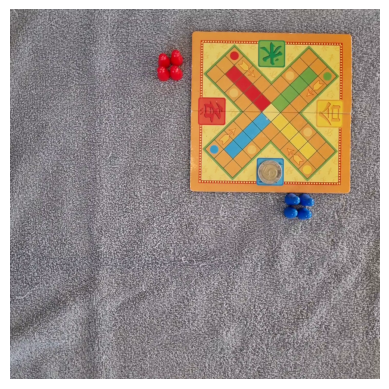

In [52]:
imshow(ludo)

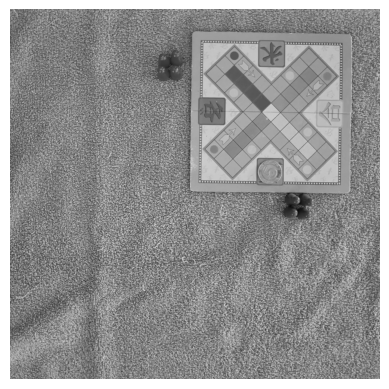

In [53]:
ludo_gray = cv2.cvtColor(ludo, cv2.COLOR_BGR2GRAY)
imshow(ludo_gray)

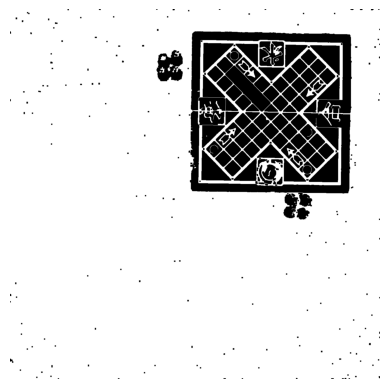

In [54]:
high, _ = cv2.threshold(
    ludo_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
low = 0.5 * high

ludo_canny = cv2.Canny(ludo_gray, low, high, apertureSize=3)

# Stronger morphology than CLEVR
ludo_canny = cv2.morphologyEx(
    ludo_canny,
    cv2.MORPH_CLOSE,
    kernel=np.ones((5, 5), np.uint8)
)

imshow(ludo_canny)


In [55]:
regions = np.zeros(ludo_canny.shape[:2], np.int32)
neighbours = [(-1, 0), (1, 0), (0, -1), (0, 1)]


In [58]:
def find_neighbours(img, y, x):
    c_neighbours = []
    for dy, dx in neighbours:
        ny, nx = y + dy, x + dx

        if ny < 0 or ny >= img.shape[0] or nx < 0 or nx >= img.shape[1]:
            continue

        if regions[ny, nx] > 0:
            continue

        if img[ny, nx] == 255:
            continue

        # uniformity test (binary here)
        if img[y, x] == img[ny, nx]:
            c_neighbours.append((ny, nx))

    return c_neighbours

def grow_region(img, y, x, cls):
    regions[y, x] = cls
    c_neighbours = find_neighbours(img, y, x)

    for ny, nx in c_neighbours:
        regions[ny, nx] = cls

    while c_neighbours:
        new_neighbours = []
        for ny, nx in c_neighbours:
            nn = find_neighbours(img, ny, nx)
            for _ny, _nx in nn:
                regions[_ny, _nx] = cls
            new_neighbours.extend(nn)
        c_neighbours = new_neighbours

In [59]:
cls = 1
for y in range(ludo_canny.shape[0]):
    for x in range(ludo_canny.shape[1]):
        if regions[y, x] == 0 and ludo_canny[y, x] == 0:
            grow_region(ludo_canny, y, x, cls)
            cls += 1


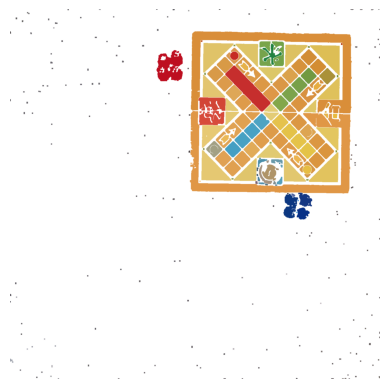

In [60]:
mean_colors = np.stack(
    [
        np.array([255, 255, 255])
        if j == 0
        else ludo[regions == j].mean(0)
        for j in range(cls)
    ],
    axis=0,
)

regions_colors = np.take(mean_colors, regions, axis=0)
regions_colors = regions_colors.astype(np.uint8)

imshow(regions_colors)


In [61]:
kernel = np.ones((5, 5), np.uint8)
edges = cv2.dilate(ludo_canny, kernel, iterations=1)

ret, labels = cv2.connectedComponents(255 - edges)


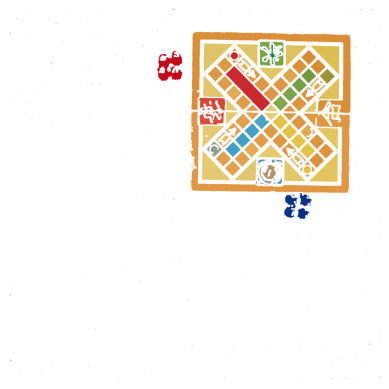

In [62]:
mean_colors = np.stack(
    [
        np.array([255, 255, 255])
        if j == 0
        else ludo[labels == j].mean(0)
        for j in range(ret)
    ],
    axis=0,
)

segmented = np.take(mean_colors, labels, axis=0).astype(np.uint8)
imshow(segmented)
